# Quickstart: look at a pattern, then fit it with Le Bail

We read a laboratory powder pattern, look at it, and fit its cell and peak shapes.
The fit uses no atomic positions.
By the end you can read a fit's summary in the order the package intends, and say whether a cell from it is worth quoting.

**You need** Python 3.11 or later and `pip install "rietx[viz]"`.
You should be comfortable running a Jupyter cell.
You do not need to have refined anything before.

**The data** is fluorapatite, Ca₅(PO₄)₃F, measured on a Bragg-Brentano diffractometer with a copper tube.
It is the `LabData` example from the GSAS-II tutorials and ships with rietx.
Its provenance and licence are in the repository's `tests/data/README.md`.

**Runtime** is under a minute on a laptop.

In [1]:
import numpy as np

import rietx as rx
from rietx.examples import examples_dir

data = rx.read_pattern(examples_dir() / "FAP.XRA")
data

PatternData of 5753 points, 15–130.04° 2θ, median step 0.02°
  intensity: <5753 floats 0…19693>
  sigma: None
  excluded_regions: none
  metadata: {source_file: 'FAP.XRA', format: 'gsas-std'}

A pattern prints as its size and range.
`sigma: None` means the file carries no uncertainty column.
The fit will weight each point by the square root of its counts instead.

## Look before fitting

Plot the pattern before any model touches it.

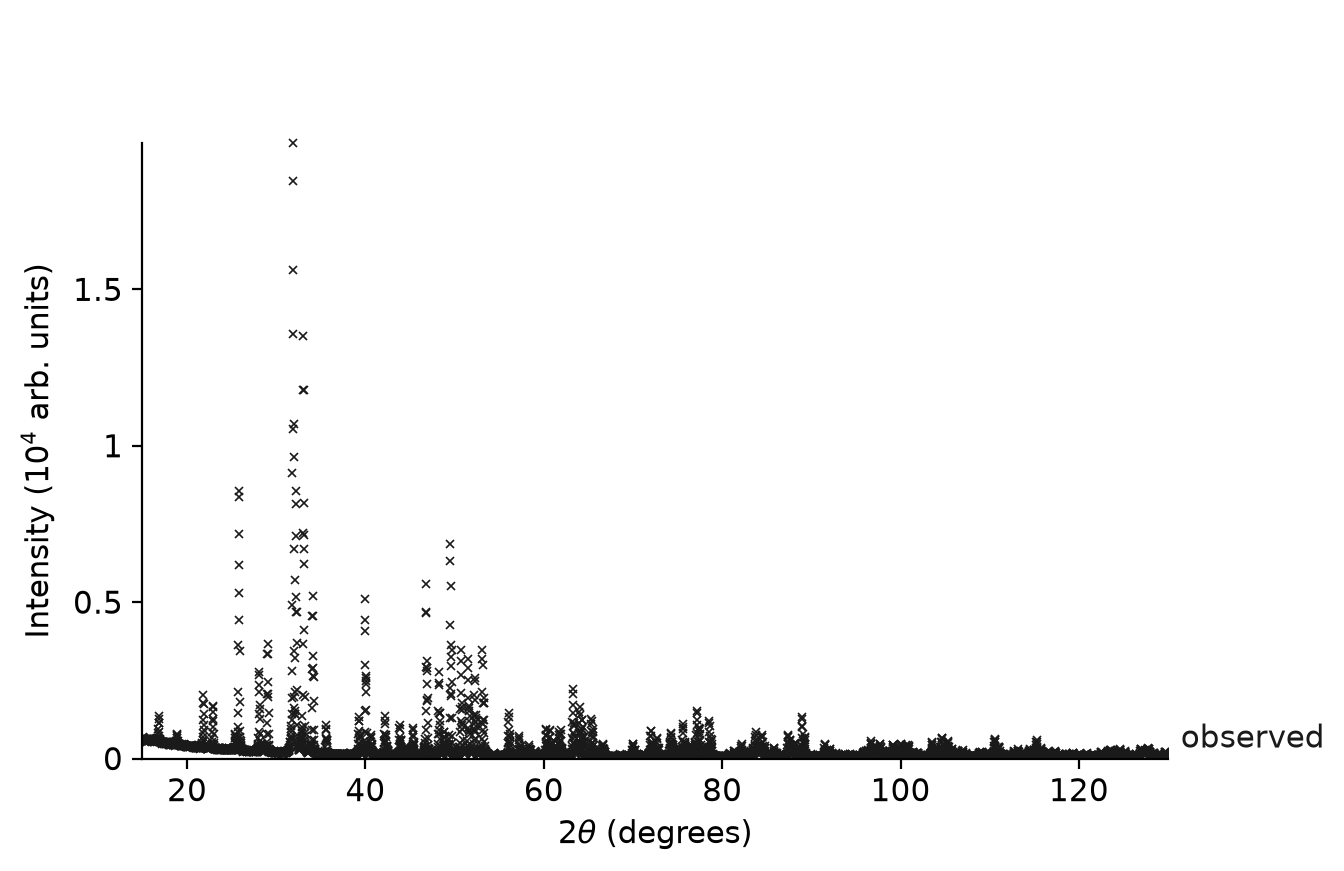

In [2]:
data.plot()

The peaks are sharp and the background is low and smooth.
Nothing in the scan looks like a second phase or a broad hump from an amorphous component, so a single-phase model is a fair start.

`rx.diagnose` measures a few things about the data that decide how it can be fitted.
We print four of its fields.
Its peak counts (`n_peaks`, `peak_fraction`, `peak_density_per_deg`) are estimates and are not quoted here.

In [3]:
diag = rx.diagnose(data)
print(f"steps across a peak's FWHM: {diag.steps_per_fwhm:.1f}")
print(f"signal over background:     {diag.signal_to_background:.0f}")
print(f"contaminating lines:        {diag.contamination or 'none'}")
print(f"dead channels:              {diag.dead_channels or 'none'}")

steps across a peak's FWHM: 4.6
signal over background:     146
contaminating lines:        none
dead channels:              none


The step count matters most.
The refinement guidelines (McCusker et al., 1999) ask for at least five measured points across each peak's full width at half maximum.
This scan has fewer, so the integrated intensities are less well measured than they could be.
No refinement choice recovers that, and the fit will say so again.

## Build a model and check it against the data

A Le Bail fit needs a cell, a space group and an instrument.
The cell and space group come from the GSAS experiment file shipped beside the pattern.
The instrument is a Bragg-Brentano diffractometer with a copper Kα doublet.

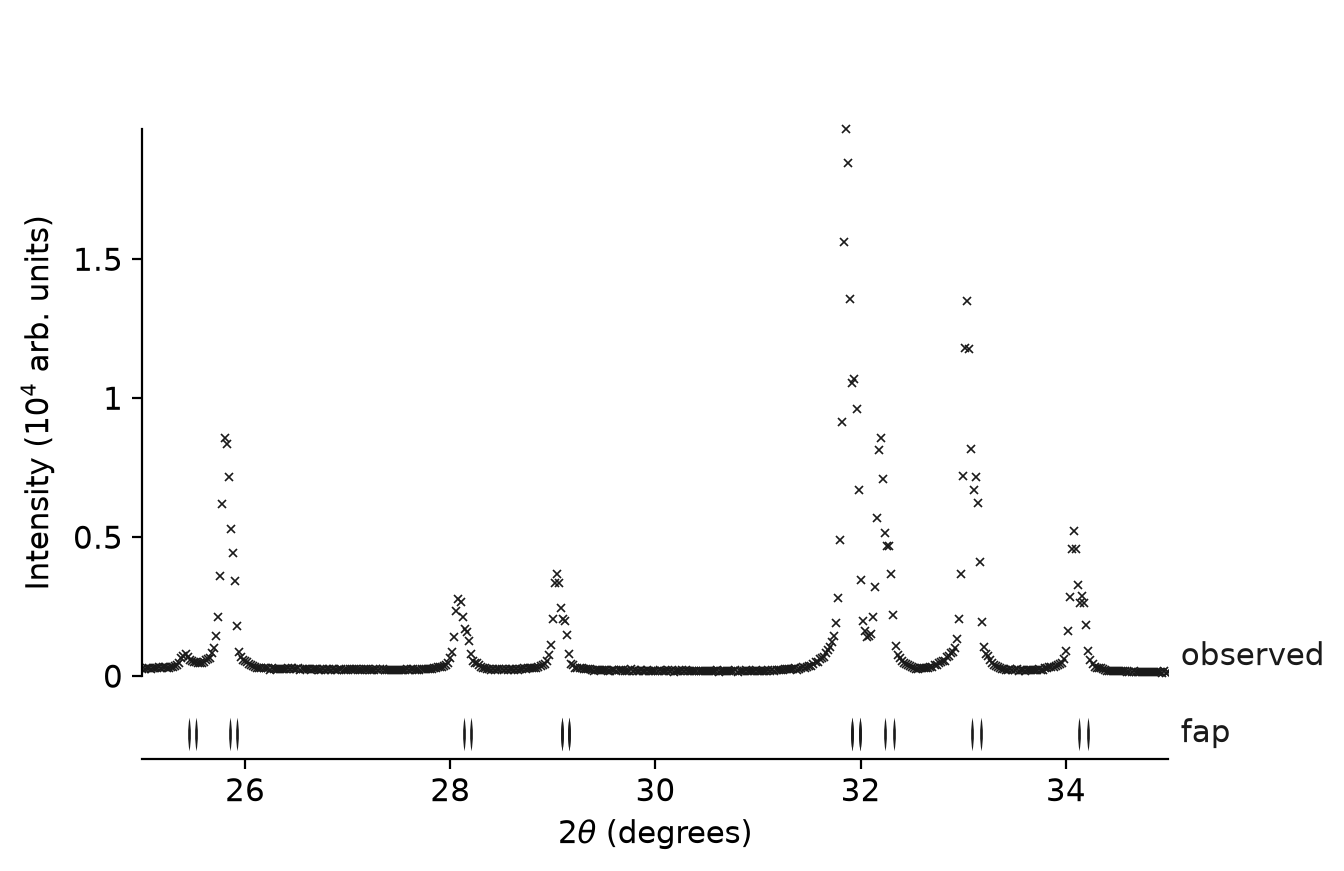

In [4]:
structure = rx.read_project_model(examples_dir() / "FAP.EXP").to_structure()

instrument = rx.Instrument.bragg_brentano(radiation="CuKa")
instrument.background = rx.BackgroundChebyshev.with_terms(6)
# Start the background's constant term at the floor of the data.
# Left at zero, the first pass hands the whole pedestal to the peaks.
instrument.background.coefficients[0].value = float(np.percentile(data.intensity, 5))

ref = rx.Refinement(structure, instrument)
data.plot(model=ref, two_theta_range=(25, 35))

The ticks under the pattern are where the model puts each reflection before any fitting.
They include the Kα2 line of each reflection, so most peaks have a pair.
Each peak should have a tick under it.
Here each pair sits slightly to the right of its peak.
That is within a fit's reach, and the zero-shift stage takes it up.
If ticks and peaks drift apart across the scan, the starting cell or the wavelength is wrong, and a fit will not walk that far.
Zoom into a few windows like this one before fitting.

The background is a six-term Chebyshev polynomial.
`rx.auto_background(data)` would size a penalised spline to the pattern instead.
On this pattern that spline currently reports each correlated pair of its coefficients as a separate warning, several hundred of them.
The polynomial keeps the diagnostics below readable.

## Fit

`mode="lebail"` extracts each reflection's intensity from the data instead of computing it from atoms.
The `profile_only` plan frees parameters in stages: background, zero shift, cell, then peak widths.
`two_theta_limits` sets the channels the fit uses.
We stop at 130° to match the GSAS-II tutorial, so both programs fit the same channels.

In [5]:
LIMITS = (15, 130)
result = ref.fit(data, mode="lebail", plan="profile_only", two_theta_limits=LIMITS)
result

path,value,at_bound
phases.0.cell.a,9.37071(12),false
phases.0.cell.b,9.37071(12),
phases.0.cell.c,6.88529(12),false
phases.0.atoms.0.z,0.001913,
phases.0.atoms.1.x,0.241976,
phases.0.atoms.1.y,0.992603,
phases.0.atoms.2.x,0.397416,
phases.0.atoms.2.y,0.367704,
phases.0.atoms.4.x,0.325053,
phases.0.atoms.4.y,0.484763,


Read the summary from the top.

1. **Status.** Every stage converged.
2. **Diagnostics.** These outrank every statistic.
   `PATTERN_UNDERSAMPLED` is the step count from `diagnose` again.
   `FROZEN_COMPILE_STALE` says the peak windows were sized at the values the last stage started from, and the cell has moved since.
   Running the plan again re-sizes them.
3. **Agreement indices** come last. Rwp is useful for comparing two fits of the same data over the same channels, and says little on its own.

## Fit again, and keep the best pass

A Le Bail fit holds its extracted intensities fixed inside each least-squares run.
The intensities and the profile converge only by alternating, so run the plan more than once.
Later passes are not guaranteed to be better, so compare them and keep the best.

In [6]:
passes = [result]
for _ in range(2):
    passes.append(ref.fit(data, mode="lebail", plan="profile_only", two_theta_limits=LIMITS))
for i, r in enumerate(passes, 1):
    print(f"pass {i}: Rwp {r.statistics.rwp:.4f}")

best = min(passes, key=lambda r: r.statistics.rwp)
ref.checkout(best.node_id)
a, c = best.parameter("phases.0.cell.a"), best.parameter("phases.0.cell.c")
print(f"kept pass {passes.index(best) + 1}: a = {a.value:.5f}({a.stderr:.5f}) Å, c = {c.value:.5f}({c.stderr:.5f}) Å")

pass 1: Rwp 0.0982
pass 2: Rwp 0.0875
pass 3: Rwp 0.0882
kept pass 2: a = 9.37090(0.00007) Å, c = 6.88532(0.00007) Å


Every pass is a node in the refinement's history, and `ref.checkout` restores the model to the one we kept.
The cell's esd is a counting-statistics figure.
It does not include any error in the wavelength or the zero shift.

## Look at the fit

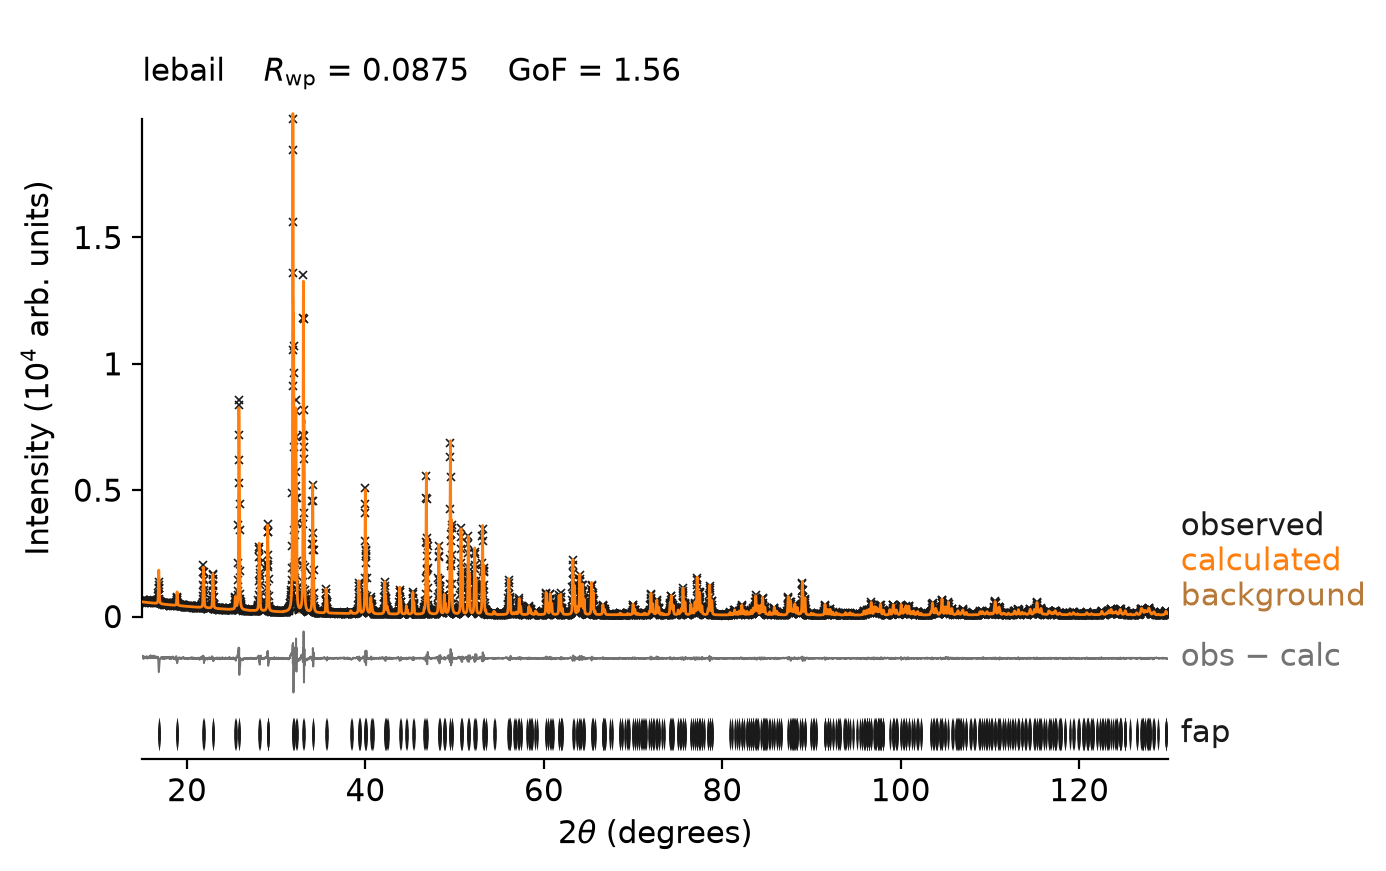

In [7]:
best.plot()

The lower panel is the difference between the data and the model.
A good fit leaves it as noise of even width across the scan.
Look for structure in it: a wiggle at every peak means the peak shape is wrong, and a peak with no tick under it means a phase the model lacks.

## Checking an agent's work

When an agent runs a fit like this for you, check these in order.
The numbers are the rules in the rietx agent skill (`SKILL.md` §4).

- **Status and diagnostics first** (rule 9). Ask the agent what each diagnostic means for its answer. "Converged" means only that the cost stopped falling.
- **The difference curve, region by region** (rule 10). A low Rwp can hide one badly fitted region.
- **Rwp last, and only against another fit of the same channels** (rule 16).
- **A Le Bail cell needs a structural check** (§2). Where reflections overlap, arbitrary intensities can index one pattern more than one way. Notebook 02 refines the same pattern with atoms.